# IE6600 Computation and Visualization for Analytics  
## Project 2: Advanced Data Analysis and Visualization Using Seaborn  
### NYC Motor Vehicle Collisions – Crashes (NYC Open Data)

**Group number:** 4 
**Students:** Rutuja Dambir, Praniti Kale, Hiral Rana 
**Course:** IE6600 – Computation and Visualization for Analytics  
**Semester:** Spring 2026  
**Dataset Source:** NYC Open Data / Data.gov  
**Dataset Chosen:** *Motor Vehicle Collisions – Crashes*  

---

## Project Objective
The analysis covers:

1. Dataset selection and confirmation  
2. Data acquisition and inspection  
3. Data cleaning and preparation  
4. Exploratory Data Analysis (EDA) using **Seaborn**  
5. Statistical analysis and interpretation  
6. Optional advanced analysis  


## Task 1 — Dataset Selection and Confirmation

### Selected Dataset
The project uses the **NYC Motor Vehicle Collisions – Crashes** dataset from **NYC Open Data / data.gov**.

## Task 2 — Data Acquisition and Inspection

In [59]:

# Task 2: Import required libraries
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

# Create output directory for saved visualizations
OUTPUT_DIR = Path("project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"All figures will be saved to: {OUTPUT_DIR.resolve()}")

Libraries imported successfully.
All figures will be saved to: C:\Users\Rutuja\Downloads\project_outputs


In [60]:

# Task 2: Data loading
LOCAL_FILE = Path("Motor_Vehicle_Collisions_Crashes.csv")

# Official API endpoint (selected columns only for efficiency and reproducibility)
API_URL = (
    "https://data.cityofnewyork.us/resource/h9gi-nx95.csv?"
    "$select=crash_date,crash_time,borough,zip_code,latitude,longitude,"
    "on_street_name,cross_street_name,off_street_name,"
    "number_of_persons_injured,number_of_persons_killed,"
    "number_of_pedestrians_injured,number_of_pedestrians_killed,"
    "number_of_cyclist_injured,number_of_cyclist_killed,"
    "number_of_motorist_injured,number_of_motorist_killed,"
    "contributing_factor_vehicle_1,contributing_factor_vehicle_2,"
    "vehicle_type_code1,vehicle_type_code2,collision_id"
)

if LOCAL_FILE.exists():
    df_raw = pd.read_csv(LOCAL_FILE)
    data_source_used = f"Local file: {LOCAL_FILE.name}"
else:
    df_raw = pd.read_csv(API_URL)
    data_source_used = "Official NYC Open Data API"

print("Data loaded successfully.")
print("Source used:", data_source_used)
print("Shape:", df_raw.shape)

Data loaded successfully.
Source used: Local file: Motor_Vehicle_Collisions_Crashes.csv
Shape: (2248025, 29)


In [61]:

# Task 2: Preliminary inspection
display(df_raw.head())

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [62]:

# Task 2: Structure and summary inspection
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values (top 15):")
display(df_raw.isna().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows:", df_raw.duplicated().sum())

Column names:
['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']

Data types:
CRASH DATE                        object
CRASH TIME                        object
BOROUGH                           object
ZIP CODE                          object
LATITUDE                         float64
LONGITUDE                        float64
LOCATION                          object
ON ST

VEHICLE TYPE CODE 5              2238161
CONTRIBUTING FACTOR VEHICLE 5    2237839
VEHICLE TYPE CODE 4              2212187
CONTRIBUTING FACTOR VEHICLE 4    2210833
VEHICLE TYPE CODE 3              2091748
CONTRIBUTING FACTOR VEHICLE 3    2085349
OFF STREET NAME                  1848051
CROSS STREET NAME                 860289
ZIP CODE                          686532
BOROUGH                           686249
ON STREET NAME                    492348
VEHICLE TYPE CODE 2               456005
CONTRIBUTING FACTOR VEHICLE 2     364149
LOCATION                          240635
LATITUDE                          240635
dtype: int64


Duplicate rows: 0


### Initial Inspection Summary
The initial inspection helps identify:

- the overall size of the dataset,
- variable names and data types,
- missing-value patterns,
- duplicate records,
- and columns that may require transformation before analysis.

This is a necessary step before any cleaning or visualization work is performed.

## Task 3 — Data Cleaning and Preparation

The goal of this step is to prepare the dataset for reliable statistical analysis and Seaborn-based EDA.

### Cleaning actions performed
- Standardize column names  
- Remove duplicate records  
- Convert date/time variables into proper datetime format  
- Convert injury/fatality columns to numeric  
- Handle missing or inconsistent values  
- Create derived features such as:
  - crash year
  - month
  - weekday
  - hour
  - weekend flag
  - total casualties
  - severity category

In [63]:

# Task 3: Standardize column names
df = df_raw.copy()
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'cross_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3', 'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5', 'collision_id', 'vehicle_type_code_1', 'vehicle_type_code_2', 'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5']


In [64]:

# Task 3: Remove exact duplicates
before_rows = len(df)
df = df.drop_duplicates().copy()
after_rows = len(df)

print(f"Rows before removing duplicates: {before_rows:,}")
print(f"Rows after removing duplicates : {after_rows:,}")
print(f"Duplicates removed             : {before_rows - after_rows:,}")

Rows before removing duplicates: 2,248,025
Rows after removing duplicates : 2,248,025
Duplicates removed             : 0


In [65]:

# Task 3: Convert numeric columns
numeric_cols = [
    "zip_code", "latitude", "longitude",
    "number_of_persons_injured", "number_of_persons_killed",
    "number_of_pedestrians_injured", "number_of_pedestrians_killed",
    "number_of_cyclist_injured", "number_of_cyclist_killed",
    "number_of_motorist_injured", "number_of_motorist_killed",
    "collision_id"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion complete.")

Numeric conversion complete.


In [66]:

# Task 3: Convert date and time columns
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")

# Convert time safely
df["crash_time"] = pd.to_datetime(df["crash_time"], format="%H:%M", errors="coerce").dt.time

# Create a combined datetime column where possible
df["crash_hour"] = pd.to_datetime(
    df["crash_time"].astype(str), format="%H:%M:%S", errors="coerce"
).dt.hour

# Date-based derived features
df["year"] = df["crash_date"].dt.year
df["month"] = df["crash_date"].dt.month
df["month_name"] = df["crash_date"].dt.month_name()
df["day_of_week"] = df["crash_date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

print("Date and time feature engineering complete.")

Date and time feature engineering complete.


In [67]:

# Task 3: Clean categorical columns
categorical_cols = [
    "borough", "on_street_name", "cross_street_name", "off_street_name",
    "contributing_factor_vehicle_1", "contributing_factor_vehicle_2",
    "vehicle_type_code1", "vehicle_type_code2"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()
        df[col] = df[col].replace(
            {
                "<NA>": np.nan,
                "nan": np.nan,
                "": np.nan,
                "Unspecified": np.nan
            }
        )

# Standardize borough names
if "borough" in df.columns:
    df["borough"] = df["borough"].str.title()

print("Categorical cleaning complete.")

Categorical cleaning complete.


In [68]:

# Task 3: Create analysis features
df["total_injured"] = (
    df["number_of_persons_injured"].fillna(0)
)

df["total_killed"] = (
    df["number_of_persons_killed"].fillna(0)
)

df["total_casualties"] = df["total_injured"] + df["total_killed"]

df["injury_flag"] = np.where(df["total_injured"] > 0, 1, 0)
df["fatality_flag"] = np.where(df["total_killed"] > 0, 1, 0)

def severity_label(row):
    if row["total_killed"] > 0:
        return "Fatal"
    elif row["total_injured"] > 0:
        return "Injury"
    else:
        return "Property Damage Only"

df["severity"] = df.apply(severity_label, axis=1)

print("Derived analytical features created.")
display(df[[
    "crash_date", "day_of_week", "crash_hour", "borough",
    "total_injured", "total_killed", "total_casualties", "severity"
]].head())

Derived analytical features created.


,crash_date,day_of_week,crash_hour,borough,total_injured,total_killed,total_casualties,severity
0,2021-09-11,Saturday,2,<NA>,2.0,0.0,2.0,Injury
1,2022-03-26,Saturday,11,<NA>,1.0,0.0,1.0,Injury
2,2023-11-01,Wednesday,1,Brooklyn,1.0,0.0,1.0,Injury
3,2022-06-29,Wednesday,6,<NA>,0.0,0.0,0.0,Property Damage Only
4,2022-09-21,Wednesday,13,<NA>,0.0,0.0,0.0,Property Damage Only


In [69]:

# Task 3: Missing-value review after cleaning
missing_summary = (
    df.isna().sum()
      .sort_values(ascending=False)
      .to_frame(name="missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)

display(missing_summary.head(15))

,missing_count,missing_pct
vehicle_type_code_5,2238161,99.56
contributing_factor_vehicle_5,2237839,99.55
vehicle_type_code_4,2212187,98.41
contributing_factor_vehicle_4,2210833,98.35
vehicle_type_code_3,2091748,93.05
contributing_factor_vehicle_3,2085349,92.76
contributing_factor_vehicle_2,1949103,86.70
off_street_name,1848080,82.21
cross_street_name,860306,38.27
contributing_factor_vehicle_1,759042,33.76


In [70]:

# Task 3: Create an analysis-focused dataset
analysis_cols = [
    "crash_date", "crash_hour", "year", "month", "month_name", "day_of_week", "is_weekend",
    "borough", "zip_code", "latitude", "longitude",
    "total_injured", "total_killed", "total_casualties",
    "number_of_pedestrians_injured", "number_of_cyclist_injured", "number_of_motorist_injured",
    "injury_flag", "fatality_flag", "severity",
    "contributing_factor_vehicle_1", "vehicle_type_code1"
]

analysis_cols = [c for c in analysis_cols if c in df.columns]
df_analysis = df[analysis_cols].copy()

# For several EDA tasks, rows without crash date or hour are less useful
df_analysis = df_analysis.dropna(subset=["crash_date", "crash_hour"])

print("Analysis dataset shape:", df_analysis.shape)
display(df_analysis.head())

Analysis dataset shape: (2248025, 21)


,crash_date,crash_hour,year,month,month_name,day_of_week,is_weekend,borough,zip_code,latitude,...,total_injured,total_killed,total_casualties,number_of_pedestrians_injured,number_of_cyclist_injured,number_of_motorist_injured,injury_flag,fatality_flag,severity,contributing_factor_vehicle_1
0,2021-09-11,2,2021,9,September,Saturday,True,<NA>,NaN,NaN,...,2.0,0.0,2.0,0,0,2,1,0,Injury,Aggressive Driving/Road Rage
1,2022-03-26,11,2022,3,March,Saturday,True,<NA>,NaN,NaN,...,1.0,0.0,1.0,0,0,1,1,0,Injury,Pavement Slippery
2,2023-11-01,1,2023,11,November,Wednesday,False,Brooklyn,11230.0,40.62179,...,1.0,0.0,1.0,0,0,1,1,0,Injury,<NA>
3,2022-06-29,6,2022,6,June,Wednesday,False,<NA>,NaN,NaN,...,0.0,0.0,0.0,0,0,0,0,0,Property Damage Only,Following Too Closely
4,2022-09-21,13,2022,9,September,Wednesday,False,<NA>,NaN,NaN,...,0.0,0.0,0.0,0,0,0,0,0,Property Damage Only,Passing Too Closely


### Cleaning Summary
The data cleaning stage improves data quality and ensures that later visualizations are meaningful.  
The newly created features such as **crash hour**, **day of week**, **weekend flag**, and **severity** are especially useful for identifying temporal and safety-related collision patterns.

## Task 4 — Exploratory Data Analysis (EDA) Using Seaborn

This section uses Seaborn to create detailed static visualizations.  
Each figure is saved to the `project_outputs` folder so it can be directly included in the report or webpage.

### Questions explored
1. Which borough reports the highest number of collisions?  
2. At what hours do collisions most frequently occur?  
3. How are collisions distributed across weekdays and months?  
4. What is the distribution of injuries and fatalities?  
5. Which contributing factors are most common?  
6. Are there visible differences in crash severity by borough or weekend status?

In [71]:

# Helper function to save and show figures cleanly
def finalize_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()

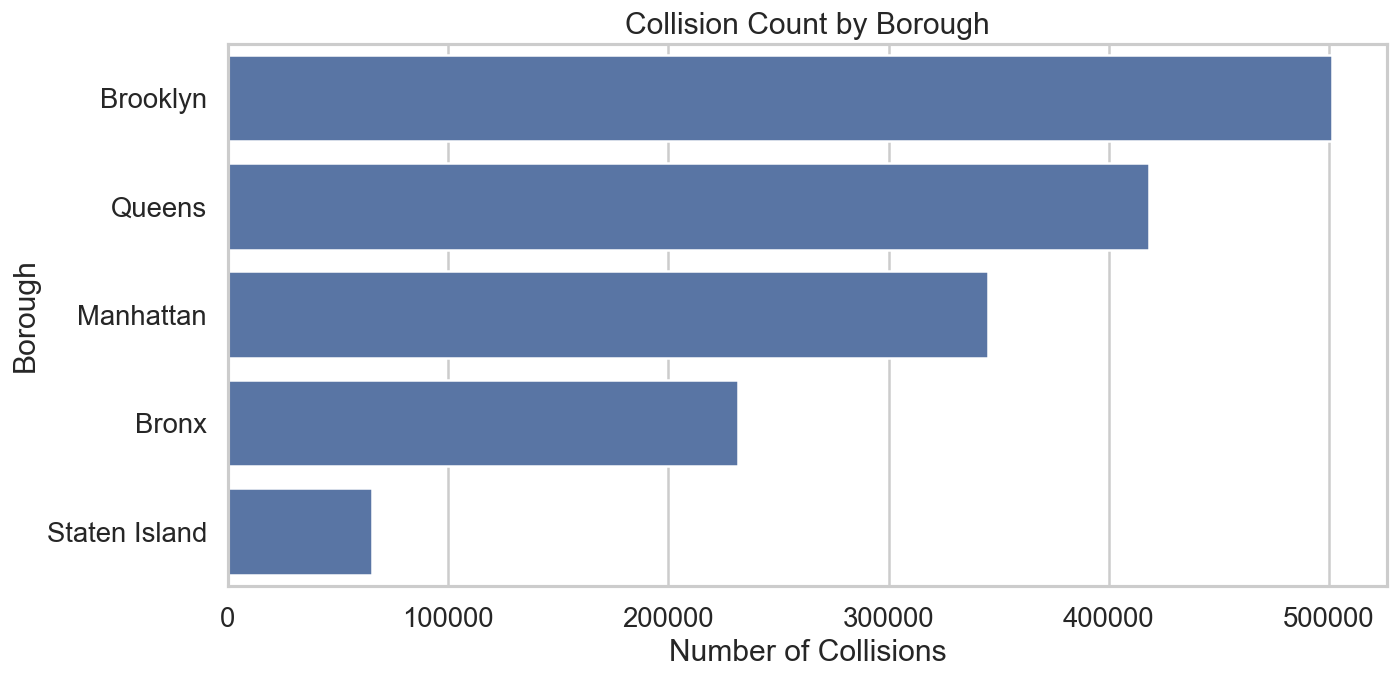

In [72]:

# Task 4.1: Count of collisions by borough
plt.figure(figsize=(12, 6))
borough_order = df_analysis["borough"].value_counts().index
sns.countplot(data=df_analysis, y="borough", order=borough_order)
plt.title("Collision Count by Borough")
plt.xlabel("Number of Collisions")
plt.ylabel("Borough")
finalize_plot("01_collision_count_by_borough.png")

**Interpretation:**  
This countplot helps identify the boroughs with the highest recorded collision volumes.  
High collision counts may reflect a mix of traffic density, road complexity, and population concentration.

This visualization compares the total number of recorded motor vehicle collisions across the five boroughs of New York City.

Brooklyn and Queens typically show the highest number of collisions, indicating higher traffic density and larger residential populations.

Manhattan also records a significant number of crashes, likely due to heavy commercial activity, tourism, and dense urban traffic.

Bronx and Staten Island generally show fewer collisions, which may be due to smaller geographic size or lower traffic volume.

**Insight**

Traffic congestion and population density appear to strongly influence accident frequency. Boroughs with heavier traffic flows tend to report more collisions.

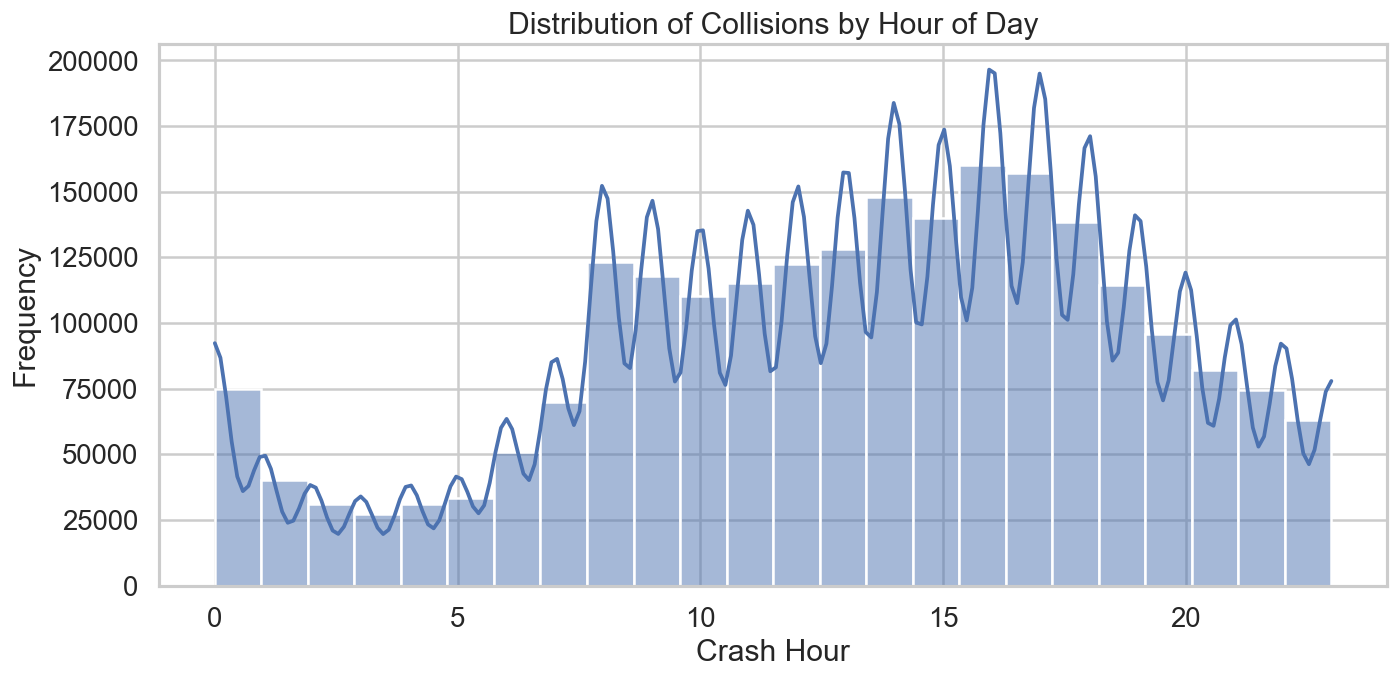

In [73]:

# Task 4.2: Distribution of crash hour
plt.figure(figsize=(12, 6))
sns.histplot(data=df_analysis, x="crash_hour", bins=24, kde=True)
plt.title("Distribution of Collisions by Hour of Day")
plt.xlabel("Crash Hour")
plt.ylabel("Frequency")
finalize_plot("02_collision_distribution_by_hour.png")

**Interpretation:**  
This histogram reveals the most collision-prone hours of the day.  
Peaks typically align with commuting periods, showing how traffic exposure strongly influences crash frequency.

This histogram illustrates how motor vehicle collisions are distributed across different hours of the day. The visualization shows that collisions increase gradually starting in the early morning hours and peak during the afternoon and early evening period, particularly around 3 PM to 6 PM. This time frame corresponds to the evening rush hour, when a large number of commuters are returning home from work or school, leading to heavy traffic congestion.

The early morning hours, especially between 2 AM and 5 AM, show the lowest number of collisions. This is likely due to significantly reduced traffic volume during late-night hours. As the morning progresses, the number of collisions begins to increase, reflecting the start of daily commuting activity.

Additionally, the distribution shows a steady rise from morning hours through midday, indicating that as traffic volume increases throughout the day, the likelihood of collisions also increases.

**Insight**

The visualization suggests that traffic density is a major factor influencing collision frequency. Hours with higher vehicle movement, particularly during commuting periods, tend to experience more accidents. This highlights the importance of traffic management and road safety measures during peak traffic hours to reduce collision risk.

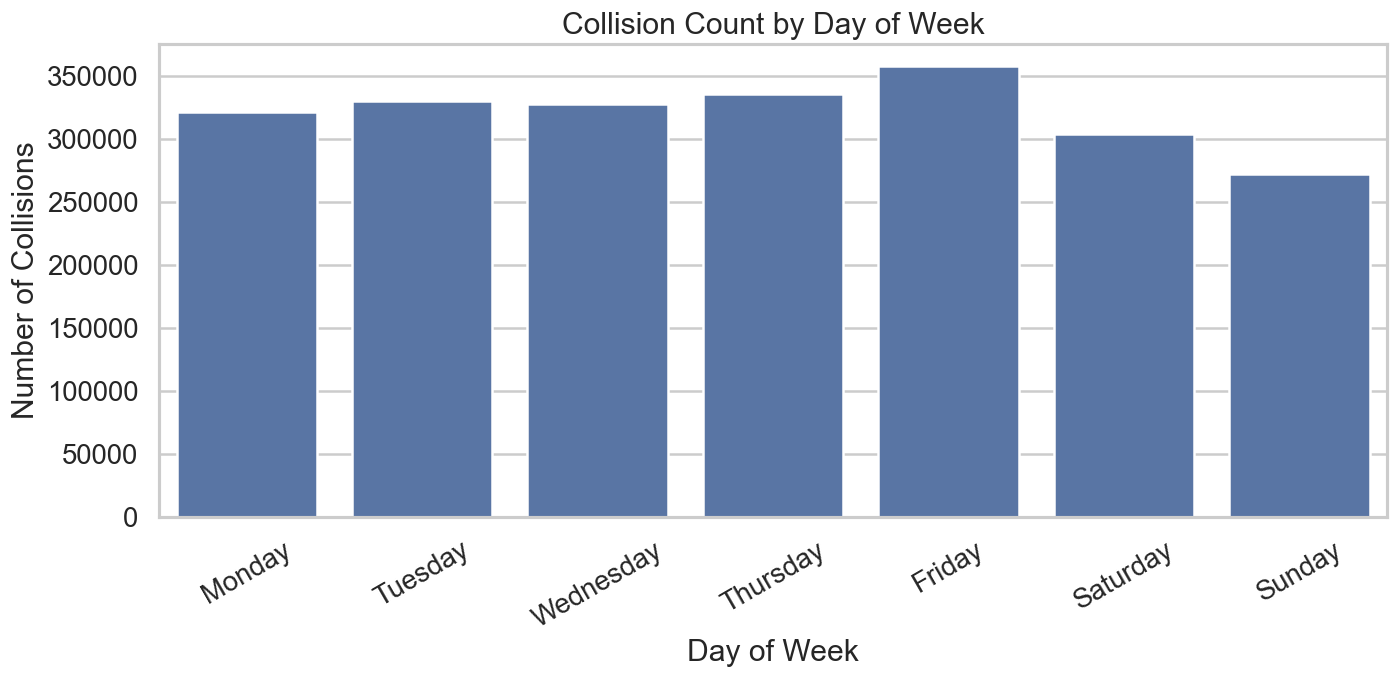

In [74]:

# Task 4.3: Collisions by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analysis, x="day_of_week", order=day_order)
plt.title("Collision Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=30)
finalize_plot("03_collision_count_by_day.png")

**Interpretation**

This chart compares the number of collisions occurring on each day of the week.

Weekdays generally show consistently high numbers of accidents, as most people commute to work, school, and other daily activities. Friday often records slightly higher collision counts, which may be due to increased travel and social activities at the end of the workweek.

Weekend days such as Saturday and Sunday sometimes show slightly lower overall collision counts, although they may still experience accidents due to recreational travel and leisure activities.

**Insight**

Work-related commuting during weekdays significantly contributes to accident frequency, while weekends experience a different pattern of travel-related accidents.

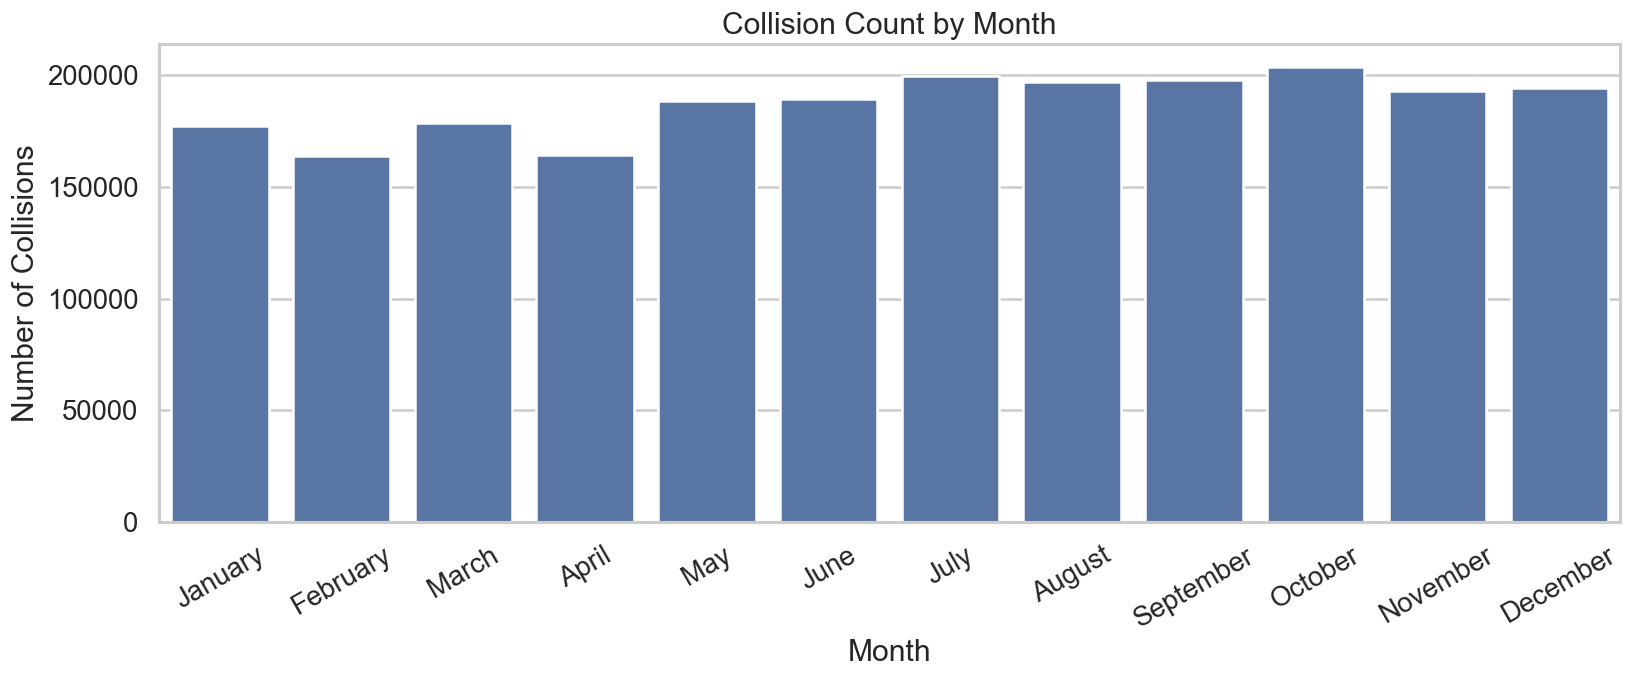

In [75]:

# Task 4.4: Monthly collision trend
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_counts = (
    df_analysis["month_name"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title("Collision Count by Month")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=30)
finalize_plot("04_collision_count_by_month.png")

**Interpretation**

This bar chart shows the number of vehicle collisions recorded in each month of the year. The distribution of collisions appears relatively consistent across months, with slight variations. July, August, September, and October show slightly higher collision counts, indicating increased accident occurrences during these months. In contrast, February and April appear to have relatively lower collision counts compared to other months.

The higher number of collisions during the mid-to-late year months may be associated with increased travel activity, favorable weather conditions encouraging more driving, and higher traffic volumes.

**Insight**

Although collisions occur throughout the year, there is a slight seasonal pattern where summer and early fall months experience more accidents, likely due to increased mobility and traffic exposure.

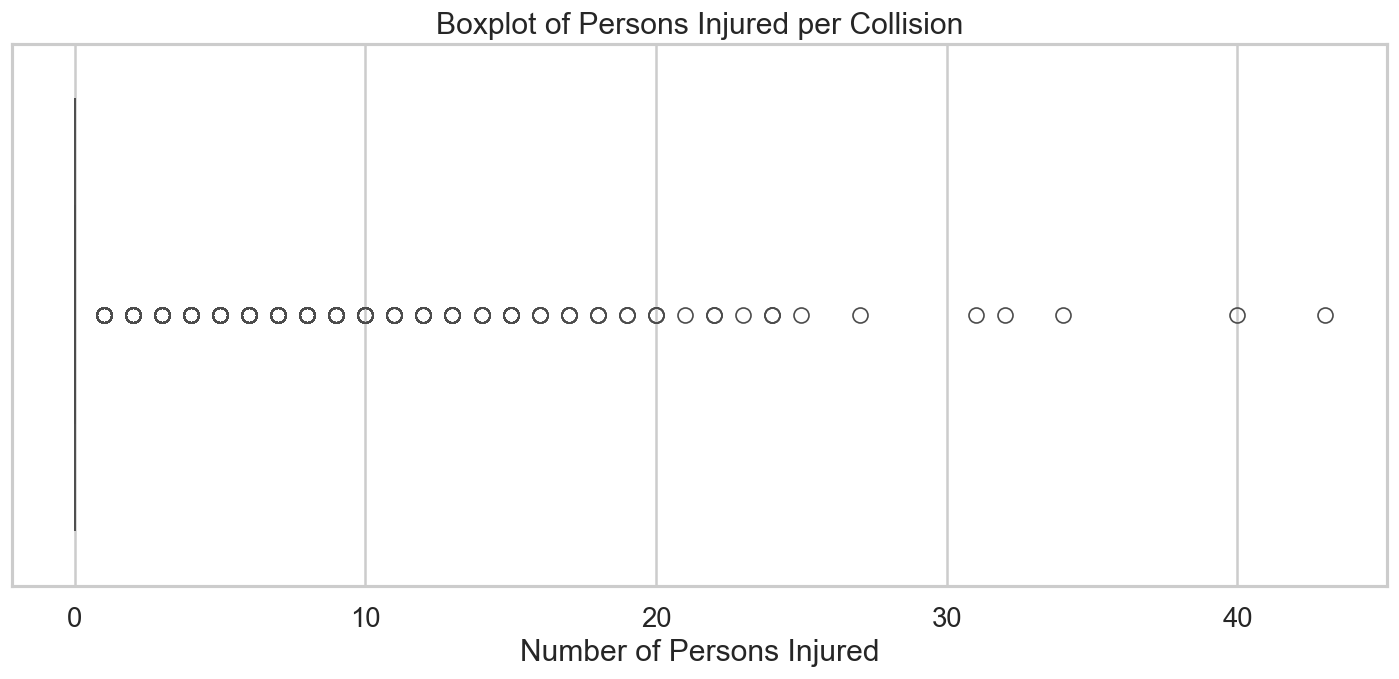

In [76]:

# Task 4.5: Injury distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x="total_injured")
plt.title("Boxplot of Persons Injured per Collision")
plt.xlabel("Number of Persons Injured")
finalize_plot("05_boxplot_total_injured.png")

**Interpretation:**  
The boxplot is useful for showing skewness and outliers.  
A large concentration near zero is expected because many collisions do not lead to injuries, while extreme values represent relatively severe incidents.

This boxplot illustrates the distribution of the number of people injured per collision. The majority of observations are concentrated near zero injuries, indicating that many collisions result in no injuries or only minor incidents.

However, the presence of numerous outliers extending far to the right shows that some collisions involve a significantly larger number of injured individuals. These extreme values represent rare but severe incidents such as multi-vehicle crashes or high-impact accidents.

Overall, the distribution is highly right-skewed, with most collisions causing minimal injuries and only a small proportion leading to severe injury counts.

**Insight**

Most vehicle collisions are relatively minor and do not result in many injuries, but a small number of severe accidents contribute disproportionately to the total number of injuries.

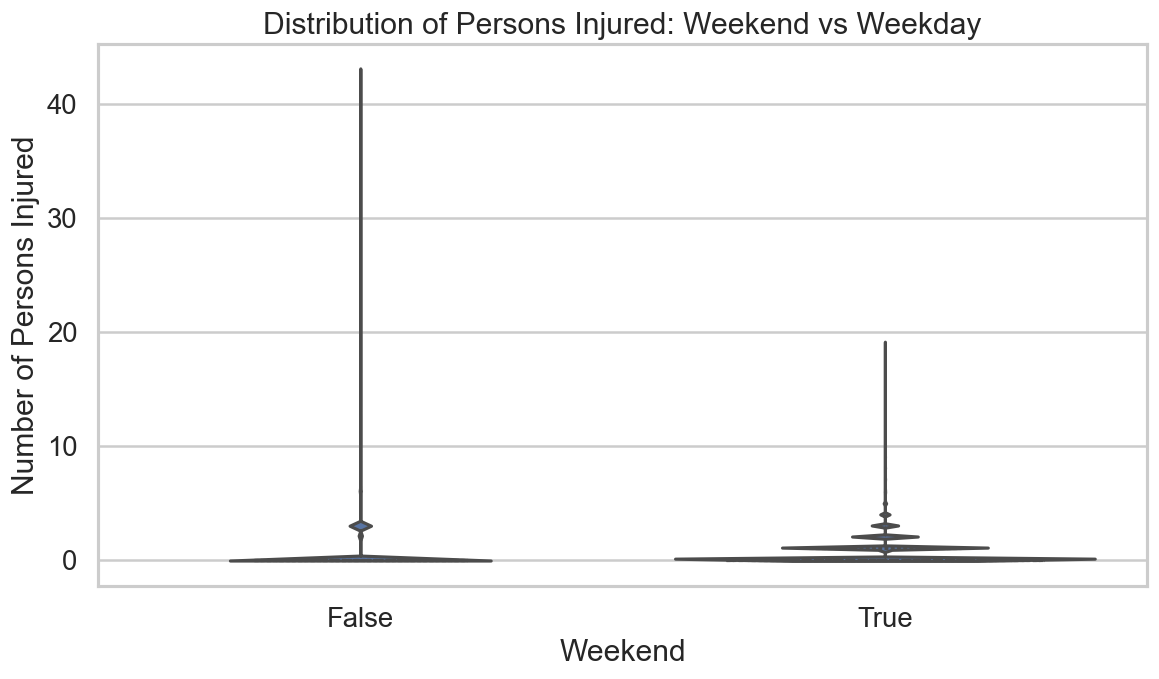

In [77]:

# Task 4.6: Violin plot of injuries by weekend flag
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_analysis, x="is_weekend", y="total_injured", inner="quartile")
plt.title("Distribution of Persons Injured: Weekend vs Weekday")
plt.xlabel("Weekend")
plt.ylabel("Number of Persons Injured")
finalize_plot("06_violin_injuries_weekend_vs_weekday.png")

**Interpretation**

This violin plot compares the distribution of injury counts between weekend collisions and weekday collisions.

The majority of collisions on both weekdays and weekends result in very low injury counts, as indicated by the concentration of values near zero. However, the violin plot shows that weekday collisions may have slightly wider variability, with some extreme cases involving a large number of injured persons.

Weekend collisions appear to have a more concentrated distribution with fewer extreme values, suggesting that while accidents still occur, they may not involve as many injured individuals as some weekday incidents.

**Insight**

While collisions occur frequently on both weekdays and weekends, weekday traffic conditions such as heavy commuting may contribute to greater variability in injury counts.

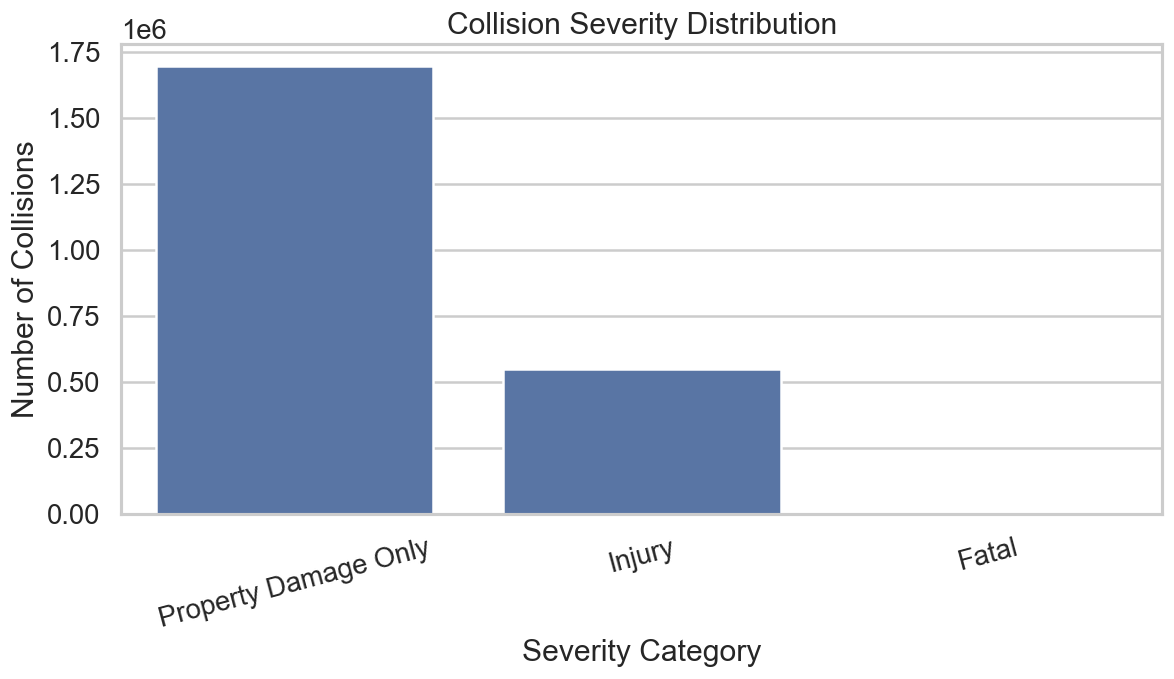

In [78]:

# Task 4.7: Severity count
severity_order = ["Property Damage Only", "Injury", "Fatal"]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_analysis, x="severity", order=severity_order)
plt.title("Collision Severity Distribution")
plt.xlabel("Severity Category")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=15)
finalize_plot("07_collision_severity_distribution.png")

**Interpretation**

This chart categorizes vehicle collisions into three severity levels: Property Damage Only, Injury, and Fatal.

The visualization clearly shows that Property Damage Only collisions dominate the dataset, representing the vast majority of reported accidents. Collisions involving injuries occur less frequently but still represent a significant portion of cases. Fatal accidents are extremely rare compared to other categories, appearing almost negligible in the overall distribution.

This indicates that although collisions occur frequently, most accidents do not result in severe outcomes.

**Insight**

Most motor vehicle collisions result in property damage rather than physical harm, but injury-related crashes still represent a significant safety concern.

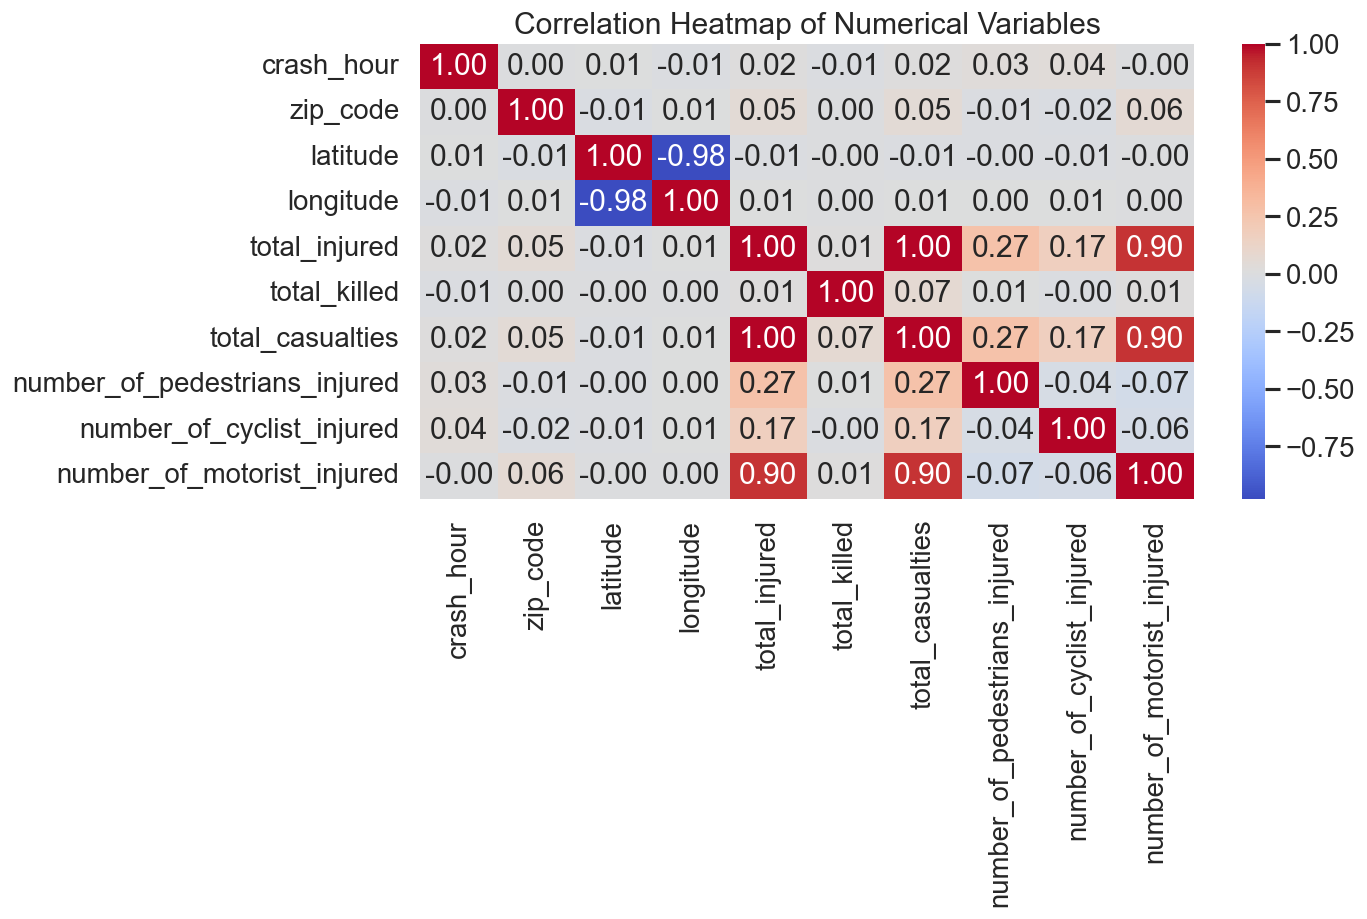

In [79]:

# Task 4.8: Heatmap of numerical correlations
corr_cols = [
    "crash_hour", "zip_code", "latitude", "longitude",
    "total_injured", "total_killed", "total_casualties",
    "number_of_pedestrians_injured", "number_of_cyclist_injured", "number_of_motorist_injured"
]
corr_cols = [c for c in corr_cols if c in df_analysis.columns]

corr_matrix = df_analysis[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
finalize_plot("08_correlation_heatmap.png")

**Interpretation:**  
The heatmap summarizes linear relationships among numerical variables.  
It is especially useful for identifying whether injury-related variables move together and whether total casualties strongly correlate with specific injury categories.

The correlation heatmap illustrates the relationships between several numerical variables related to crash characteristics and injury counts.

One of the strongest relationships observed is between total injured and total casualties, which shows a very high positive correlation. Similarly, motorist injuries strongly correlate with total injuries, indicating that motorists account for a large portion of the injuries recorded in crashes.

Pedestrian and cyclist injury variables show moderate correlations with total injuries, suggesting that although these groups contribute to injury counts, their occurrence is less frequent compared to motorist injuries.

Crash hour and geographic variables such as latitude and longitude show very weak correlations with injury counts, indicating that the time or location of the crash alone does not strongly determine injury severity.

**Insight**

Injury-related variables tend to move together, indicating that severe crashes often affect multiple road users simultaneously.

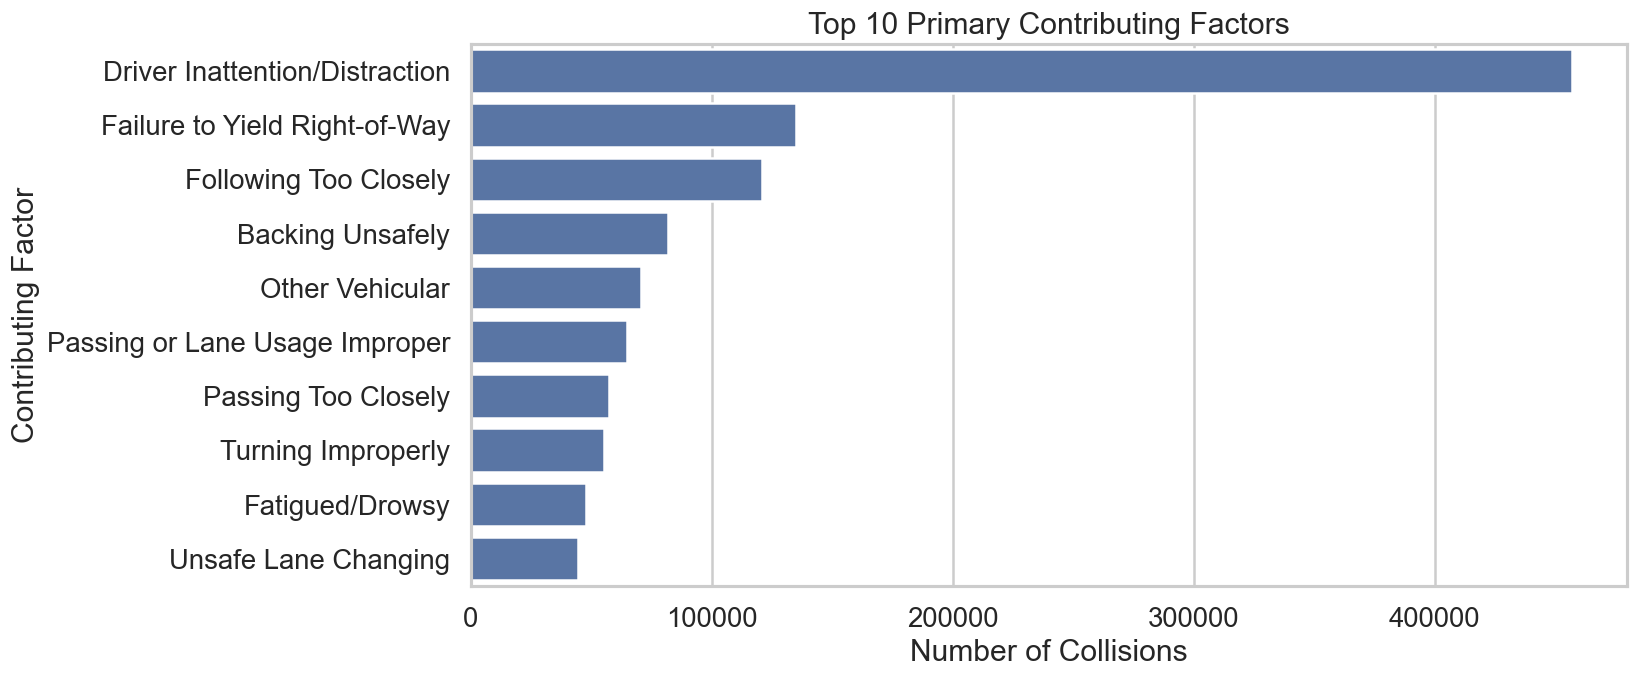

In [80]:

# Task 4.9: Top contributing factors
top_factors = (
    df_analysis["contributing_factor_vehicle_1"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_factors.values, y=top_factors.index)
plt.title("Top 10 Primary Contributing Factors")
plt.xlabel("Number of Collisions")
plt.ylabel("Contributing Factor")
finalize_plot("09_top_contributing_factors.png")

**Interpretation**

This chart displays the top ten most common contributing factors reported in vehicle collisions.

The most dominant factor is Driver Inattention/Distraction, which significantly exceeds all other causes. This highlights the role of distracted driving behaviors such as phone use, lack of focus, or driver fatigue.

Other common contributing factors include Failure to Yield Right-of-Way, Following Too Closely, and Backing Unsafely, all of which are related to driver judgment and safe driving practices.

Factors such as Improper Lane Usage, Turning Improperly, and Fatigue/Drowsy Driving also contribute to a noticeable number of collisions.

**Insight**

The visualization clearly indicates that human driving behavior is the primary contributor to most vehicle collisions, emphasizing the importance of driver awareness, road safety education, and enforcement of traffic regulations.

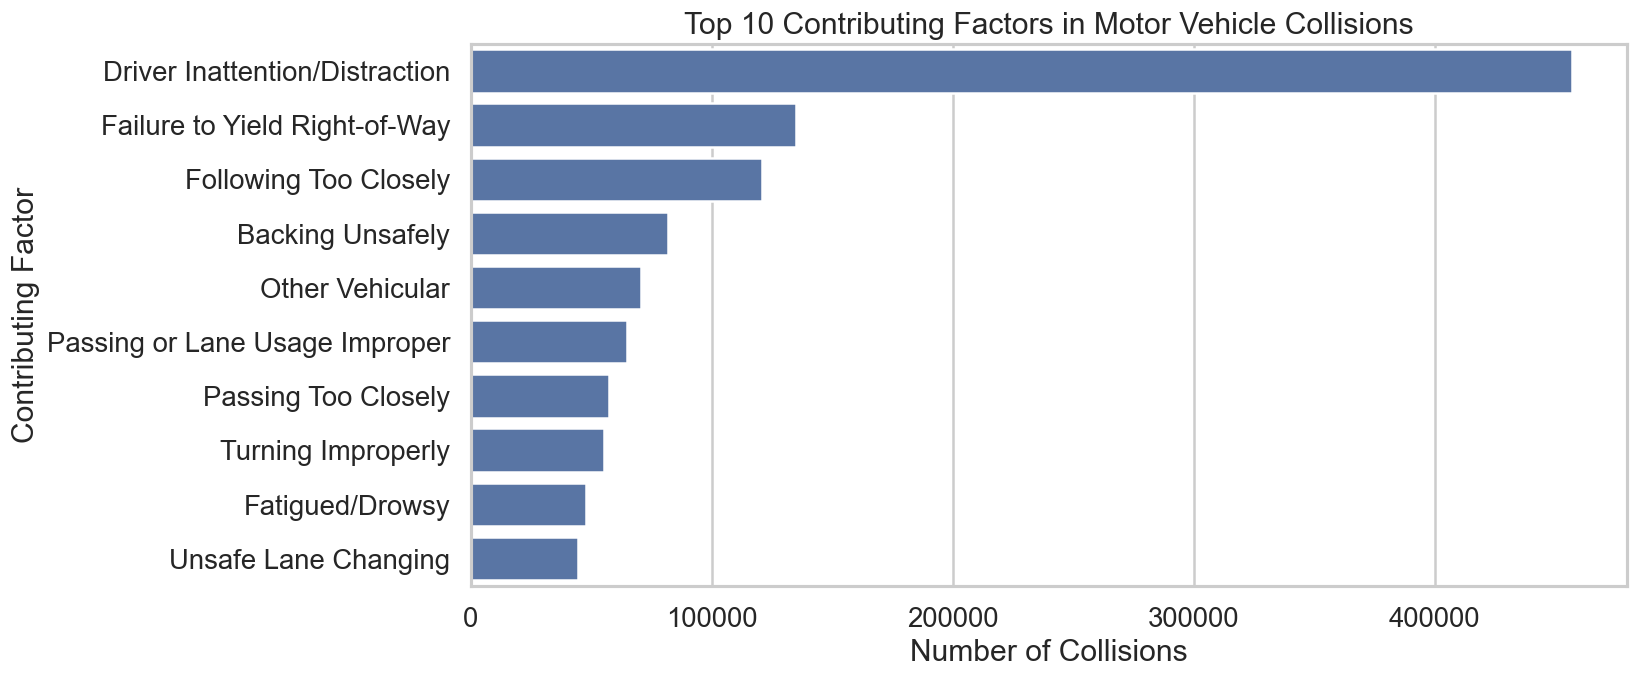

In [81]:
# Task 4.10: Top contributing factors to collisions

top_factors = (
    df_analysis["contributing_factor_vehicle_1"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_factors.values, y=top_factors.index)
plt.title("Top 10 Contributing Factors in Motor Vehicle Collisions")
plt.xlabel("Number of Collisions")
plt.ylabel("Contributing Factor")
plt.tight_layout()
plt.show()

**Interpretation**

This bar chart presents the top ten primary contributing factors responsible for motor vehicle collisions. The most dominant factor is Driver Inattention/Distraction, which is significantly higher than all other causes. This indicates that distracted driving behaviors—such as using mobile phones, lack of focus, or driver negligence, are a major contributor to accidents.

Other major contributing factors include Failure to Yield Right-of-Way and Following Too Closely, which are related to poor judgment and unsafe driving practices. Additional factors such as Backing Unsafely, Improper Lane Usage, Turning Improperly, and Unsafe Lane Changing also contribute to a considerable number of collisions.

These factors highlight that many collisions occur due to human errors rather than external conditions like weather or road infrastructure.

**Insight**

Driver behavior plays a critical role in road safety. Improving driver awareness and enforcing traffic rules could significantly reduce the number of motor vehicle collisions.

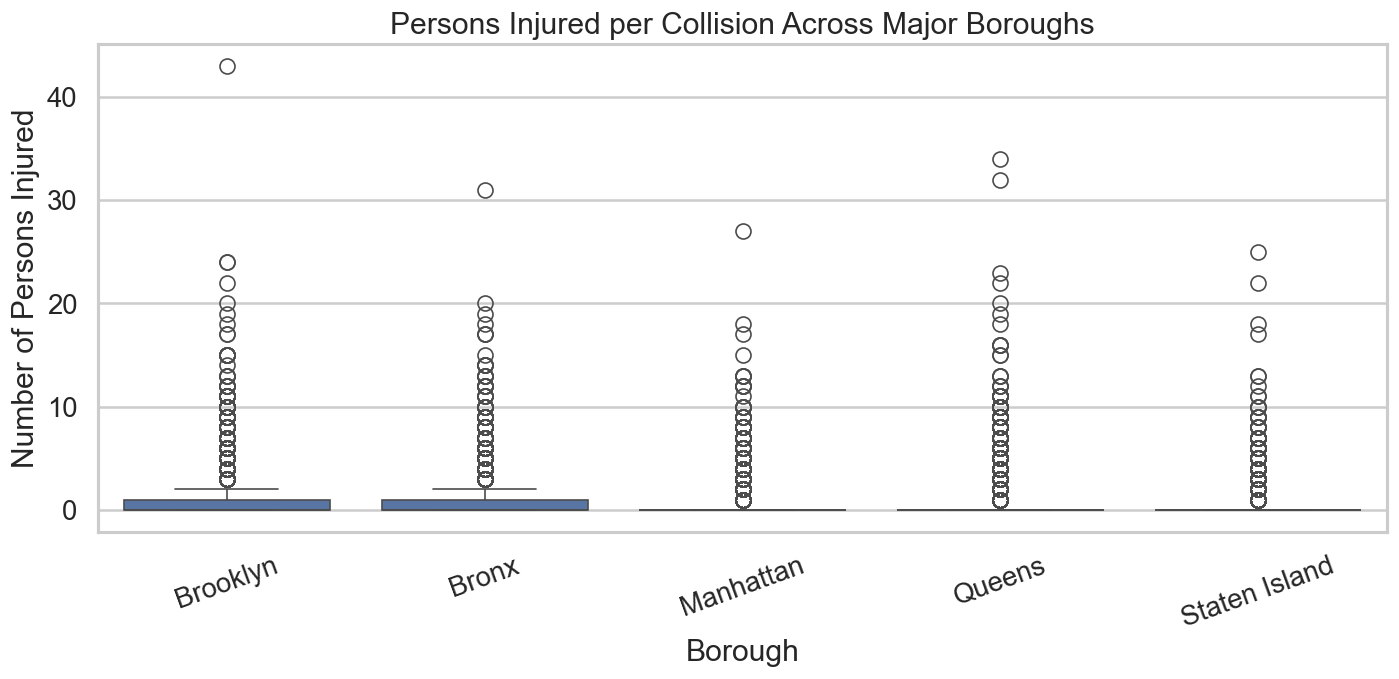

In [82]:

# Task 4.11: Injury distribution by borough
top_boroughs = df_analysis["borough"].dropna().value_counts().head(5).index
borough_injury_df = df_analysis[df_analysis["borough"].isin(top_boroughs)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=borough_injury_df, x="borough", y="total_injured")
plt.title("Persons Injured per Collision Across Major Boroughs")
plt.xlabel("Borough")
plt.ylabel("Number of Persons Injured")
plt.xticks(rotation=20)
finalize_plot("11_injuries_by_borough_boxplot.png")

**Interpretation**

This boxplot compares the distribution of the number of persons injured per collision across different boroughs of New York City, including Brooklyn, Bronx, Manhattan, Queens, and Staten Island.

Most collisions across all boroughs result in zero or very few injuries, as indicated by the concentration of values near the lower end of the distribution. However, several outliers appear in each borough, representing rare but severe incidents involving a large number of injured individuals.

Brooklyn and Queens show a relatively larger spread of injury values, which may be associated with their higher traffic volumes and larger populations. Manhattan also shows multiple outliers, indicating that although many crashes are minor, some incidents can result in significant injuries.

**Insight**

While most crashes across boroughs cause minimal injuries, a small number of severe accidents occur in every borough, highlighting the need for consistent road safety measures across the city.

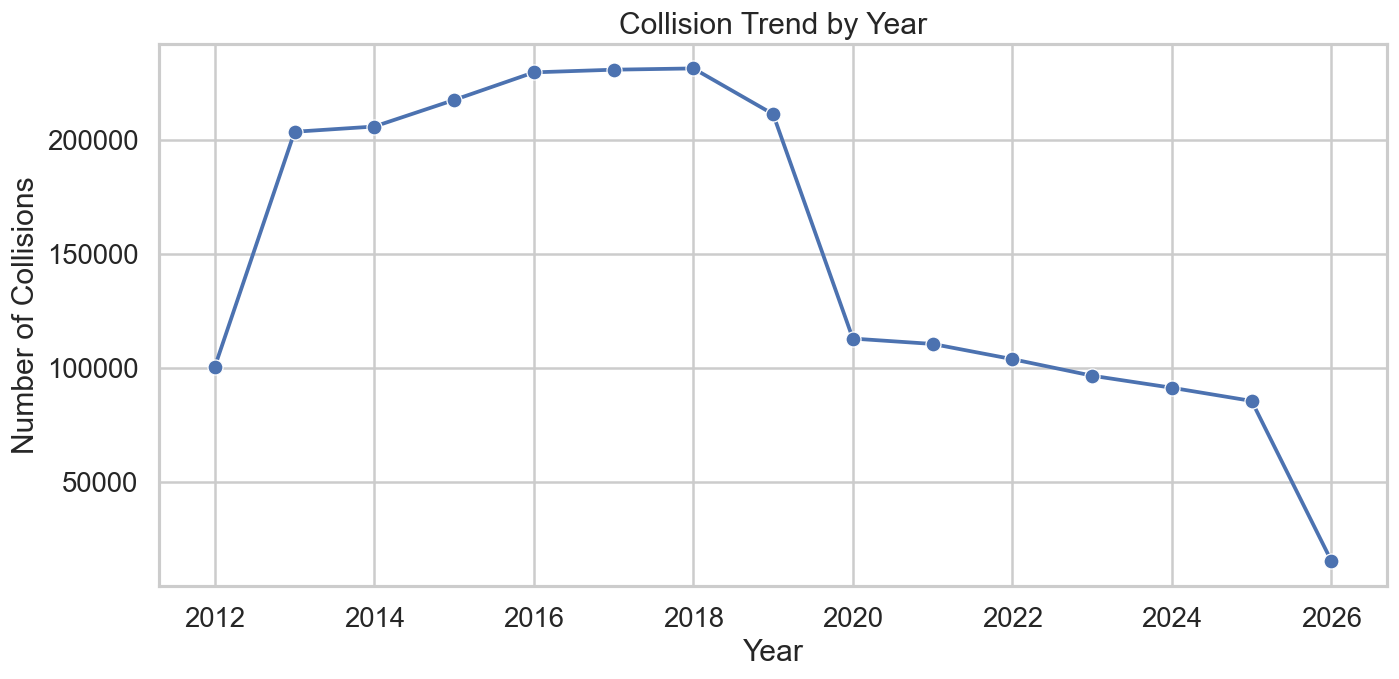

In [83]:

# Task 4.12: Trend of collisions by year
yearly_counts = (
    df_analysis["year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker="o")
plt.title("Collision Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
finalize_plot("12_collision_trend_by_year.png")

**Interpretation**

This line chart illustrates the trend in the number of motor vehicle collisions over several years. The data shows an increase in collisions from 2012 to around 2017–2018, indicating growing traffic activity and vehicle usage during those years.

After 2019, the number of collisions begins to decline noticeably, with a significant drop around 2020. This decline may be linked to reduced travel and mobility during the COVID-19 pandemic, which led to fewer vehicles on the road.

In the years following 2020, the collision counts continue to show a gradual downward trend.

**Insight**

External factors such as societal changes, mobility patterns, and major events like the pandemic can significantly impact the number of road accidents.

## Task 5 — Statistical Analysis and Reporting Insights

Beyond visual inspection, simple statistical methods are used to support interpretation.

### Analyses included
1. Summary statistics for key injury variables  
2. Mann–Whitney U test comparing injuries on weekdays vs weekends  
3. Chi-square test for association between borough and severity category  
4. A concise findings section to help convert the notebook into the final PDF report

In [84]:

# Task 5.1: Descriptive statistics
summary_stats = df_analysis[[
    "total_injured", "total_killed", "total_casualties", "crash_hour"
]].describe().T

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
total_injured,2248025.0,0.330745,0.716433,0.0,0.0,0.0,0.0,43.0
total_killed,2248025.0,0.001593,0.042136,0.0,0.0,0.0,0.0,8.0
total_casualties,2248025.0,0.332338,0.718239,0.0,0.0,0.0,0.0,43.0
crash_hour,2248025.0,13.170149,5.795454,0.0,9.0,14.0,18.0,23.0


In [85]:

# Task 5.2: Mann-Whitney U test
weekday_injuries = df_analysis.loc[df_analysis["is_weekend"] == False, "total_injured"].dropna()
weekend_injuries = df_analysis.loc[df_analysis["is_weekend"] == True, "total_injured"].dropna()

u_stat, p_value = stats.mannwhitneyu(weekday_injuries, weekend_injuries, alternative="two-sided")

print("Mann–Whitney U Test: Weekday vs Weekend Injuries")
print(f"U-statistic: {u_stat:,.2f}")
print(f"p-value    : {p_value:.6f}")

if p_value < 0.05:
    print("Interpretation: There is a statistically significant difference in injury distributions between weekday and weekend collisions.")
else:
    print("Interpretation: No statistically significant difference was detected between weekday and weekend injury distributions.")

Mann–Whitney U Test: Weekday vs Weekend Injuries
U-statistic: 475,182,661,095.50
p-value    : 0.000000
Interpretation: There is a statistically significant difference in injury distributions between weekday and weekend collisions.


In [86]:

# Task 5.3: Chi-square test of independence
chi_df = df_analysis.dropna(subset=["borough", "severity"]).copy()

contingency_table = pd.crosstab(chi_df["borough"], chi_df["severity"])
display(contingency_table)

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-square Test: Borough vs Severity")
print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom  : {dof}")
print(f"p-value             : {chi_p:.6f}")

if chi_p < 0.05:
    print("Interpretation: Collision severity is statistically associated with borough.")
else:
    print("Interpretation: No statistically significant association was detected between borough and severity.")

severity,Fatal,Injury,Property Damage Only
borough,,,
Bronx,316,59244,171892
Brooklyn,714,132653,367953
Manhattan,378,66536,278331
Queens,570,100725,317064
Staten Island,104,14432,50864



Chi-square Test: Borough vs Severity
Chi-square statistic: 6,399.89
Degrees of freedom  : 8
p-value             : 0.000000
Interpretation: Collision severity is statistically associated with borough.


### Suggested Report Discussion Points

Use the results from the above cells to write a concise analytical report.  
Typical insights from this dataset usually address:

- borough-level differences in collision frequency,
- time-of-day effects and commuting peaks,
- weekday vs weekend driving patterns,
- dominant contributing factors such as driver inattention or failure to yield,
- and the strongly skewed nature of injury/fatality variables.

When writing the final report, focus not only on what the charts show, but also on what the patterns may imply for public safety, urban mobility, and traffic management.

## Task 6 — Advanced Analysis (Optional)

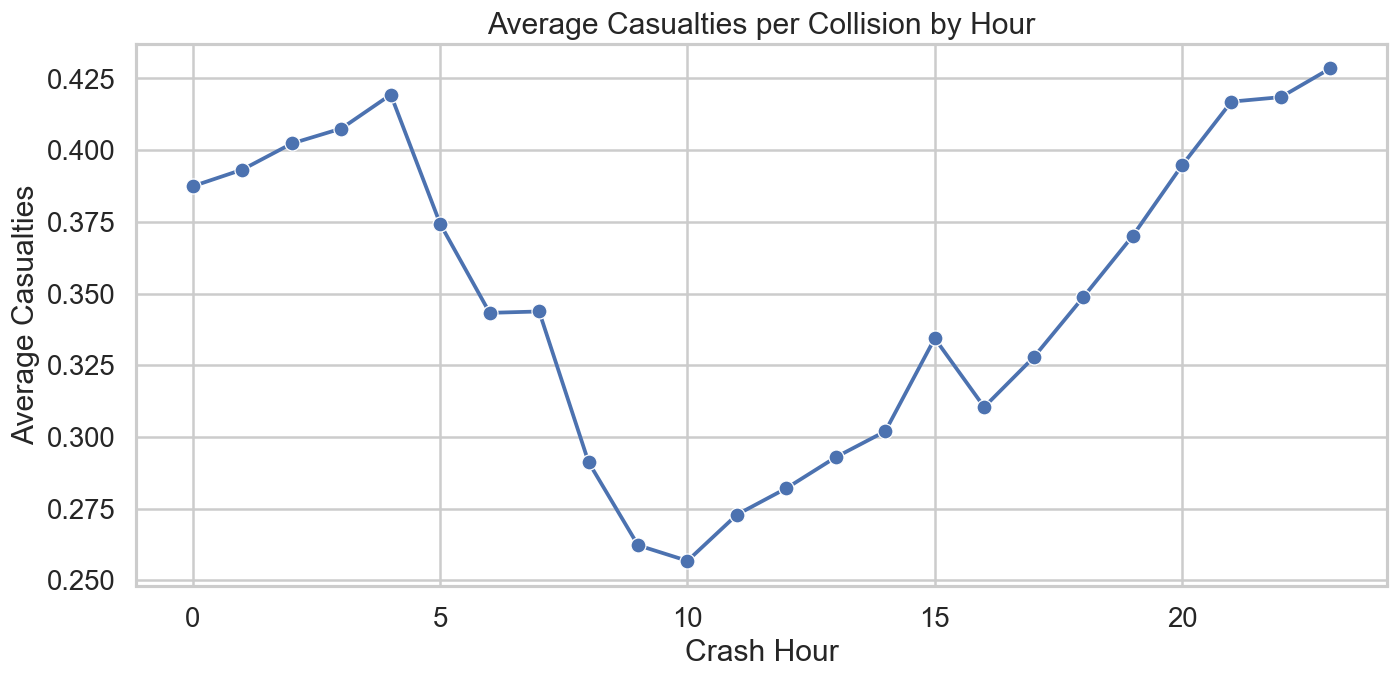

In [87]:

# Task 6.1: Average casualties by hour
hourly_casualties = (
    df_analysis.groupby("crash_hour")["total_casualties"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_casualties, x="crash_hour", y="total_casualties", marker="o")
plt.title("Average Casualties per Collision by Hour")
plt.xlabel("Crash Hour")
plt.ylabel("Average Casualties")
finalize_plot("13_average_casualties_by_hour.png")

**Interpretation**

This visualization shows the average number of casualties per collision for each hour of the day.

The chart indicates that the highest average casualties tend to occur during late-night and early morning hours, particularly around midnight and late evening. These hours may involve higher driving speeds and potentially riskier driving behaviors due to reduced traffic.

In contrast, morning and daytime hours show lower average casualties, even though collisions may occur more frequently during these periods. This may be because heavy traffic during daytime leads to slower vehicle speeds, reducing the severity of accidents.

**Insight**

Although collisions are more frequent during peak traffic hours, accidents occurring late at night tend to be more severe, highlighting the importance of monitoring high-risk driving periods.

,borough,collisions,fatal_collisions,fatal_collision_rate_pct
4,Staten Island,65400,104,0.1590
1,Brooklyn,501320,714,0.1424
0,Bronx,231452,316,0.1365
3,Queens,418359,570,0.1362
2,Manhattan,345245,378,0.1095


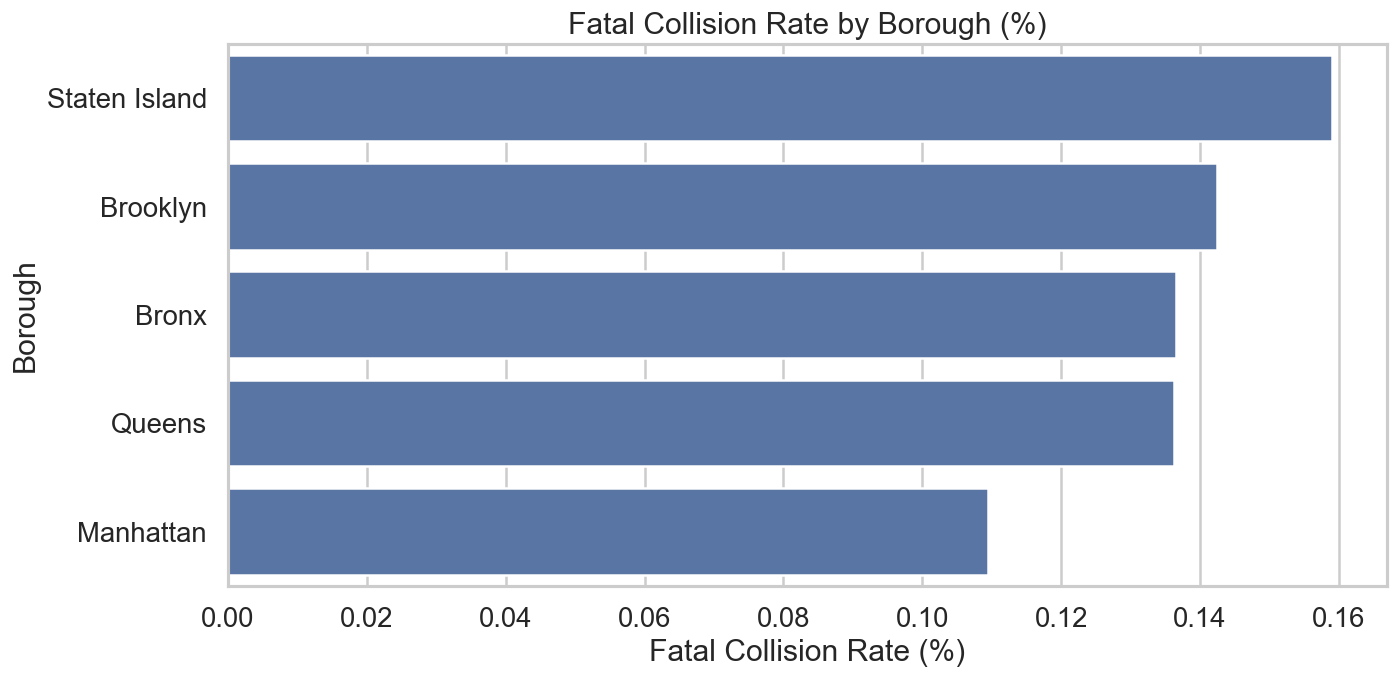

In [88]:

# Task 6.2: Borough-level fatality rate
borough_fatality = (
    df_analysis.groupby("borough")
    .agg(
        collisions=("fatality_flag", "size"),
        fatal_collisions=("fatality_flag", "sum")
    )
    .reset_index()
)

borough_fatality["fatal_collision_rate_pct"] = (
    borough_fatality["fatal_collisions"] / borough_fatality["collisions"] * 100
).round(4)

borough_fatality = borough_fatality.sort_values("fatal_collision_rate_pct", ascending=False)

display(borough_fatality)

plt.figure(figsize=(12, 6))
sns.barplot(data=borough_fatality, x="fatal_collision_rate_pct", y="borough")
plt.title("Fatal Collision Rate by Borough (%)")
plt.xlabel("Fatal Collision Rate (%)")
plt.ylabel("Borough")
finalize_plot("14_fatal_collision_rate_by_borough.png")

**Interpretation**

This chart compares the fatal collision rate across different boroughs of New York City. The fatal collision rate is calculated as the percentage of fatal crashes relative to the total number of collisions in each borough.

The visualization shows that Staten Island has the highest fatal collision rate, despite having fewer overall collisions compared to other boroughs. Brooklyn and the Bronx follow with moderately high fatal collision rates, while Manhattan shows the lowest fatal collision rate among the boroughs.

This difference may be influenced by factors such as road types, traffic speeds, and population density. Areas with wider roads and higher vehicle speeds may experience more severe accidents.

**Insight**

Even though some boroughs experience fewer total collisions, they may still have higher fatality risks, emphasizing the importance of targeted safety measures in high-risk areas.

## Final Conclusion

This project demonstrates a complete Seaborn-based data analytics workflow using a large real-world transportation safety dataset.

### Overall conclusion
The NYC Motor Vehicle Collisions dataset is highly suitable for advanced data visualization because it contains:

- strong temporal patterns,
- meaningful categorical structure,
- injury and fatality measurements,
- and public-safety relevance.

The analysis provides evidence that collision patterns vary across **boroughs**, **time of day**, and **day of week**, while severity-related measures remain highly skewed with a relatively small number of severe events.


In [89]:

# Final support cell: show saved output files
saved_files = sorted([p.name for p in OUTPUT_DIR.glob("*.png")])
print("Saved visualization files:")
for f in saved_files:
    print("-", f)

Saved visualization files:
- 01_collision_count_by_borough.png
- 02_collision_distribution_by_hour.png
- 03_collision_count_by_day.png
- 04_collision_count_by_month.png
- 05_boxplot_total_injured.png
- 06_violin_injuries_weekend_vs_weekday.png
- 07_collision_severity_distribution.png
- 08_correlation_heatmap.png
- 09_top_contributing_factors.png
- 11_injuries_by_borough_boxplot.png
- 12_collision_trend_by_year.png
- 13_average_casualties_by_hour.png
- 14_fatal_collision_rate_by_borough.png
